# Breno Alves de Oliveira

# LISTA DE EXECÍCIOS 2
     PL SOLUÇÃO GRÁFICA

### Problema 1:
Um sapateiro faz 6 sapatos por hora, se fizer somente sapatos, e 5 cintos por hora, se fizer somente
cintos.

Ele gasta 2 unidades de couro para fabricar 1 unidade de sapato e 1 unidade de couro para
fabricar uma unidade de cinto. 

Sabendo-se que o total disponível de couro é de 6 unidades e que o lucro unitário por sapato é de 5 unidades monetárias e o do cinto é de 2 unidades monetárias, pede-se: 
- o modelo do sistema de produção do sapateiro, se o objetivo é maximizar seu lucro por hora.


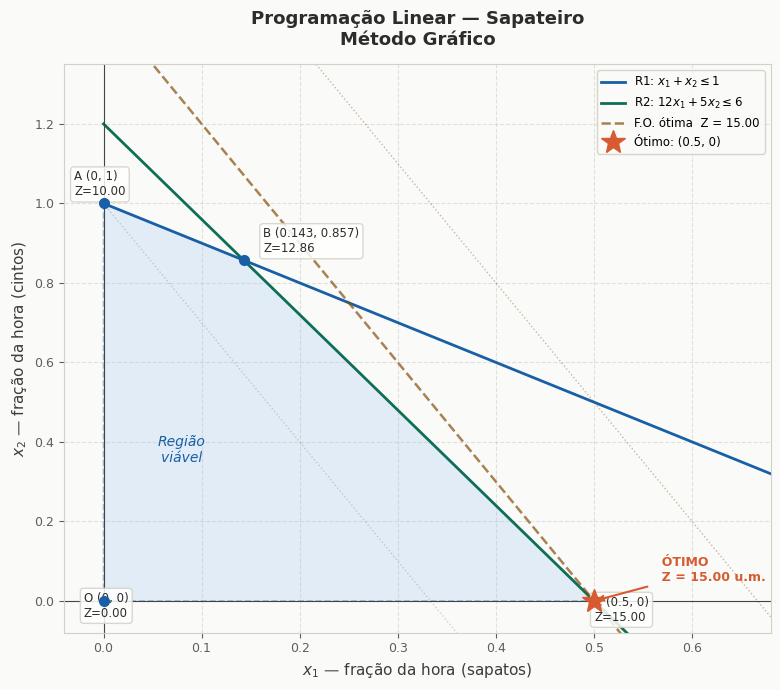

In [7]:
"""
Programação Linear — Sapateiro (Método Gráfico)
================================================

Variáveis de decisão:
    x1 = fração da hora dedicada a sapatos
    x2 = fração da hora dedicada a cintos

Produção por hora:
    sapatos: 6·x1 unidades  (lucro unitário = 5 u.m.)
    cintos : 5·x2 unidades  (lucro unitário = 2 u.m.)

Função objetivo:
    Max Z = 5·(6x1) + 2·(5x2) = 30x1 + 10x2

Restrições:
    R1 — tempo disponível : x1  + x2  ≤ 1
    R2 — couro disponível : 12x1 + 5x2 ≤ 6
    R3 — não-negatividade : x1 ≥ 0, x2 ≥ 0
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import linprog


# linprog minimiza → negamos os coeficientes
c    = [-30, -10]
A_ub = [[ 1,  1],
        [12,  5]]
b_ub = [1, 6]
bounds = [(0, None), (0, None)]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
x1_opt, x2_opt = res.x
Z_opt = -res.fun


# -------------------------------------------------------
# 3. GRÁFICO
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

x = np.linspace(0, 0.7, 400)

# --- linhas de restrição ---
x2_R1 = 1 - x                          # R1: x2 = 1 - x1
x2_R2 = (6 - 12*x) / 5                 # R2: x2 = (6 - 12x1) / 5

ax.plot(x, x2_R1, color='#185FA5', linewidth=2,   label='R1: $x_1 + x_2 \\leq 1$')
ax.plot(x, x2_R2, color='#0F6E56', linewidth=2,   label='R2: $12x_1 + 5x_2 \\leq 6$')

# --- região viável ---
# Vértices: O(0,0), C(0.5,0), B(1/7,6/7), A(0,1)
vertices = np.array([
    [0,     0  ],
    [0.5,   0  ],
    [1/7,   6/7],
    [0,     1  ],
])
poly = plt.Polygon(vertices, closed=True,
                   facecolor='#B5D4F4', alpha=0.35,
                   edgecolor='#185FA5', linewidth=1.2, linestyle='--')
ax.add_patch(poly)
ax.text(0.08, 0.35, 'Região\nviável', fontsize=10,
        color='#185FA5', ha='center', style='italic')

# --- linhas de nível da F.O. (isocustas) ---
for z_val, alpha in [(10, 0.25), (20, 0.4), (Z_opt, 0.0)]:
    # Z = 30x1 + 10x2  →  x2 = (Z - 30x1)/10
    x2_iso = (z_val - 30*x) / 10
    ax.plot(x, x2_iso, color='#854F0B', linewidth=1,
            linestyle=':', alpha=alpha)
# linha ótima destacada
x2_iso_opt = (Z_opt - 30*x) / 10
ax.plot(x, x2_iso_opt, color='#854F0B', linewidth=1.8,
        linestyle='--', alpha=0.7, label=f'F.O. ótima  Z = {Z_opt:.2f}')

# --- vértices anotados ---
pontos = {
    'O': (0,     0,    'left',  'bottom'),
    'A': (0,     1,    'left',  'bottom'),
    'B': (1/7,   6/7,  'right', 'bottom'),
    'C': (0.5,   0,    'center','top'   ),
}
for nome, (px, py, ha, va) in pontos.items():
    z_v = 30*px + 10*py
    ax.plot(px, py, 'o', color='#185FA5', markersize=7, zorder=5)
    offset = {'O': (-0.02, -0.04), 'A': (-0.03, 0.02),
              'B': ( 0.02,  0.02), 'C': ( 0.0,  -0.05)}[nome]
    ax.annotate(
        f'{nome} ({px:.3g}, {py:.3g})\nZ={z_v:.2f}',
        xy=(px, py),
        xytext=(px + offset[0], py + offset[1]),
        fontsize=8.5, color='#2C2C2A',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#D3D1C7', alpha=0.85)
    )

# --- ponto ótimo destacado ---
ax.plot(x1_opt, x2_opt, '*', color='#D85A30', markersize=18,
        zorder=6, label=f'Ótimo: ({x1_opt:.3g}, {x2_opt:.3g})')
ax.annotate(
    f'  ÓTIMO\n  Z = {Z_opt:.2f} u.m.',
    xy=(x1_opt, x2_opt), xytext=(x1_opt+0.06, x2_opt+0.05),
    fontsize=9, color='#D85A30', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5)
)

# --- eixos e grade ---
ax.axhline(0, color='#444441', linewidth=0.8)
ax.axvline(0, color='#444441', linewidth=0.8)
ax.set_xlim(-0.04, 0.68)
ax.set_ylim(-0.08, 1.35)
ax.set_xlabel('$x_1$ — fração da hora (sapatos)', fontsize=11, color='#3d3d3a')
ax.set_ylabel('$x_2$ — fração da hora (cintos)',  fontsize=11, color='#3d3d3a')
ax.set_title('Programação Linear — Sapateiro\nMétodo Gráfico',
             fontsize=13, fontweight='bold', color='#2C2C2A', pad=14)
ax.grid(True, linestyle='--', alpha=0.35, color='#B4B2A9')
ax.tick_params(colors='#5F5E5A', labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#D3D1C7')

ax.legend(loc='upper right', fontsize=8.5,
          framealpha=0.9, edgecolor='#D3D1C7',
          facecolor='#FAFAF8')

plt.tight_layout()
plt.show()
plt.close()


### Problema 2:
Certa empresa fabrica 2 produtos P1 e P2. 
O lucro por unidade de P1 é de 100 u.m. e o lucro unitário de P2 é de 150 u.m.

A empresa necessita de 2 horas para fabricar uma unidade de P1 e 3 horas para
fabricar uma unidade de P2. O tempo mensal disponível para essas atividades é de 120 horas.

As demandas esperadas para os 2 produtos levaram a empresa a decidir que os montantes produzidos
de P1 e P2 não devem ultrapassar 40 unidades de P1 e 30 unidades de P2 por mês. Construa o modelo
do sistema de produção mensal com o objetivo de maximizar o lucro da empresa.




Vértices da região viável e Z em cada um:
  (0.0, 0.0)  →  Z = 0.00
  (40.0, 0.0)  →  Z = 4000.00
  (40.0, 13.3)  →  Z = 5999.99
  (15.0, 30.0)  →  Z = 6000.00
  (0.0, 30.0)  →  Z = 4500.00


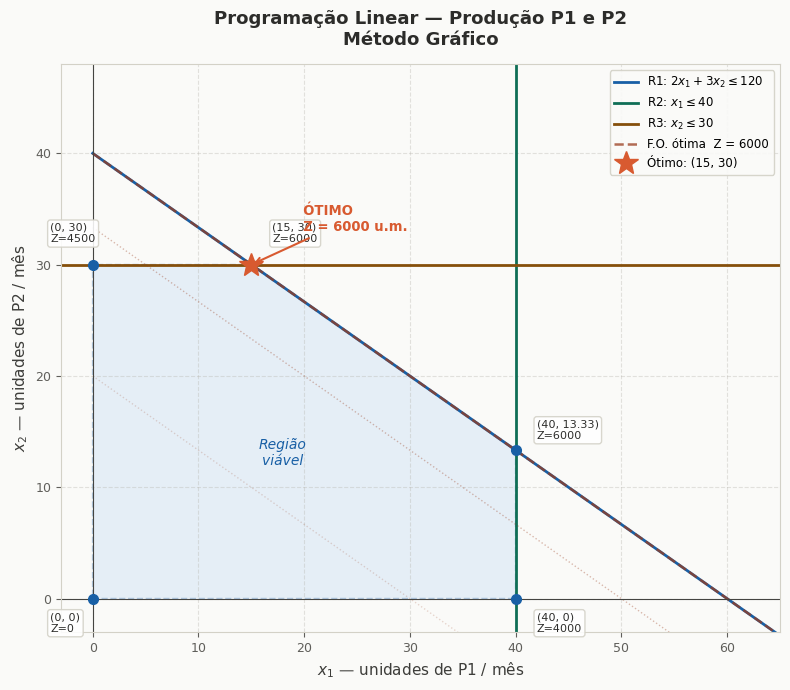

In [8]:
"""
Programação Linear — Produção de P1 e P2
=========================================

Variáveis de decisão:
    x1 = unidades de P1 produzidas por mês
    x2 = unidades de P2 produzidas por mês

Função objetivo:
    Max Z = 100·x1 + 150·x2

Restrições:
    R1 — horas disponíveis : 2x1 + 3x2 ≤ 120
    R2 — demanda máx. P1   : x1 ≤ 40
    R3 — demanda máx. P2   : x2 ≤ 30
    R4 — não-negatividade  : x1 ≥ 0, x2 ≥ 0
"""

from itertools import combinations

# -------------------------------------------------------
# 1. RESOLVER COM SCIPY
# -------------------------------------------------------
c    = [-100, -150]
A_ub = [[2, 3],
        [1, 0],
        [0, 1]]
b_ub = [120, 40, 30]
bounds = [(0, None), (0, None)]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
x1_opt, x2_opt = res.x
Z_opt = -res.fun

# -------------------------------------------------------
# 2. VÉRTICES DA REGIÃO VIÁVEL
# -------------------------------------------------------
# Candidatos a vértice: interseções de pares de fronteiras
# Fronteiras: x1=0, x2=0, x1=40, x2=30, 2x1+3x2=120

def intersect(l1, l2):
    """Resolve o sistema 2×2 de duas retas ax+by=c."""
    A_mat = np.array([l1[:2], l2[:2]], dtype=float)
    b_vec = np.array([l1[2],  l2[2]],  dtype=float)
    try:
        return np.linalg.solve(A_mat, b_vec)
    except np.linalg.LinAlgError:
        return None

linhas = [
    (1, 0, 0),    # x1 = 0
    (0, 1, 0),    # x2 = 0
    (1, 0, 40),   # x1 = 40
    (0, 1, 30),   # x2 = 30
    (2, 3, 120),  # 2x1 + 3x2 = 120
]

vertices = []
for l1, l2 in combinations(linhas, 2):
    pt = intersect(l1, l2)
    if pt is None:
        continue
    x1v, x2v = pt
    # verifica todas as restrições
    if (x1v >= -1e-9 and x2v >= -1e-9 and
        x1v <= 40 + 1e-9 and x2v <= 30 + 1e-9 and
        2*x1v + 3*x2v <= 120 + 1e-9):
        vertices.append((round(x1v, 6), round(x2v, 6)))

# Remove duplicatas e ordena
vertices = list({(round(v[0],4), round(v[1],4)) for v in vertices})

# Ordenar em sentido anti-horário (convex hull manual via ângulo)
cx = np.mean([v[0] for v in vertices])
cy = np.mean([v[1] for v in vertices])
vertices.sort(key=lambda v: np.arctan2(v[1]-cy, v[0]-cx))

print(f"\nVértices da região viável e Z em cada um:")
for vx, vy in vertices:
    zv = 100*vx + 150*vy
    print(f"  ({vx:.1f}, {vy:.1f})  →  Z = {zv:.2f}")

# -------------------------------------------------------
# 3. GRÁFICO
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

x1 = np.linspace(0, 65, 500)

# Restrições — linhas
x2_R1 = (120 - 2*x1) / 3
ax.plot(x1, x2_R1, color='#185FA5', lw=2,
        label='R1: $2x_1 + 3x_2 \\leq 120$')
ax.axvline(40, color='#0F6E56', lw=2,
           label='R2: $x_1 \\leq 40$')
ax.axhline(30, color='#854F0B', lw=2,
           label='R3: $x_2 \\leq 30$')

# Região viável
poly_pts = np.array(vertices)
poly = plt.Polygon(poly_pts, closed=True,
                   facecolor='#B5D4F4', alpha=0.30,
                   edgecolor='#185FA5', lw=1.2, linestyle='--')
ax.add_patch(poly)
ax.text(18, 12, 'Região\nviável', fontsize=10,
        color='#185FA5', ha='center', style='italic')

# Linhas de nível da F.O.
for z_val, al in [(3000, 0.20), (5000, 0.35), (Z_opt, 0.0)]:
    x2_iso = (z_val - 100*x1) / 150
    ax.plot(x1, x2_iso, color='#993C1D', lw=1,
            linestyle=':', alpha=al)
x2_iso_opt = (Z_opt - 100*x1) / 150
ax.plot(x1, x2_iso_opt, color='#993C1D', lw=1.8,
        linestyle='--', alpha=0.75,
        label=f'F.O. ótima  Z = {Z_opt:.0f}')

# Vértices anotados
offsets = {
    (0.0,   0.0):  (-4,  -3),
    (0.0,  30.0):  (-4,   2),
    (15.0, 30.0):  ( 2,   2),
    (40.0, 13.3):  ( 2,   1),
    (40.0,  0.0):  ( 2,  -3),
}
for vx, vy in vertices:
    zv = 100*vx + 150*vy
    ax.plot(vx, vy, 'o', color='#185FA5', ms=7, zorder=5)
    key = (round(vx,1), round(vy,1))
    dx, dy = offsets.get(key, (2, 1))
    ax.annotate(
        f'({vx:.4g}, {vy:.4g})\nZ={zv:.0f}',
        xy=(vx, vy), xytext=(vx+dx, vy+dy),
        fontsize=8, color='#2C2C2A',
        bbox=dict(boxstyle='round,pad=0.25', fc='white',
                  ec='#D3D1C7', alpha=0.88)
    )

# Ponto ótimo
ax.plot(x1_opt, x2_opt, '*', color='#D85A30', ms=18, zorder=6,
        label=f'Ótimo: ({x1_opt:.0f}, {x2_opt:.0f})')
ax.annotate(
    f'  ÓTIMO\n  Z = {Z_opt:.0f} u.m.',
    xy=(x1_opt, x2_opt),
    xytext=(x1_opt + 4, x2_opt + 3),
    fontsize=9.5, color='#D85A30', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5)
)

# Eixos e acabamento
ax.axhline(0, color='#444441', lw=0.8)
ax.axvline(0, color='#444441', lw=0.8)
ax.set_xlim(-3, 65)
ax.set_ylim(-3, 48)
ax.set_xlabel('$x_1$ — unidades de P1 / mês', fontsize=11, color='#3d3d3a')
ax.set_ylabel('$x_2$ — unidades de P2 / mês', fontsize=11, color='#3d3d3a')
ax.set_title('Programação Linear — Produção P1 e P2\nMétodo Gráfico',
             fontsize=13, fontweight='bold', color='#2C2C2A', pad=14)
ax.grid(True, linestyle='--', alpha=0.35, color='#B4B2A9')
ax.tick_params(colors='#5F5E5A', labelsize=9)
for sp in ax.spines.values():
    sp.set_edgecolor('#D3D1C7')

ax.legend(loc='upper right', fontsize=8.5,
          framealpha=0.9, edgecolor='#D3D1C7', facecolor='#FAFAF8')

plt.tight_layout()
plt.show()
plt.close()

> Solução ótima: produzir 15 unidades de P1 e 30 unidades de P2 por mês, gerando um lucro máximo de 6.000 u.m./mês.

### Problema 3:
Uma rede de televisão local tem o seguinte problema: foi descoberto que o programa “A” com 20
minutos de música e 1 minuto de propaganda chama a atenção de 30.000 telespectadores, enquanto
o programa “B”, com 10 minutos de música e 1 minuto de propaganda chama a atenção de 10.000
telespectadores. 

No decorrer de uma semana, o patrocinador insiste no uso de no mínimo, 5 minutos
para sua propaganda e que não há verba para mais de 80 minutos de música. 

Quantas vezes por semana cada programa deve ser levado ao ar para obter o número máximo de telespectadores?



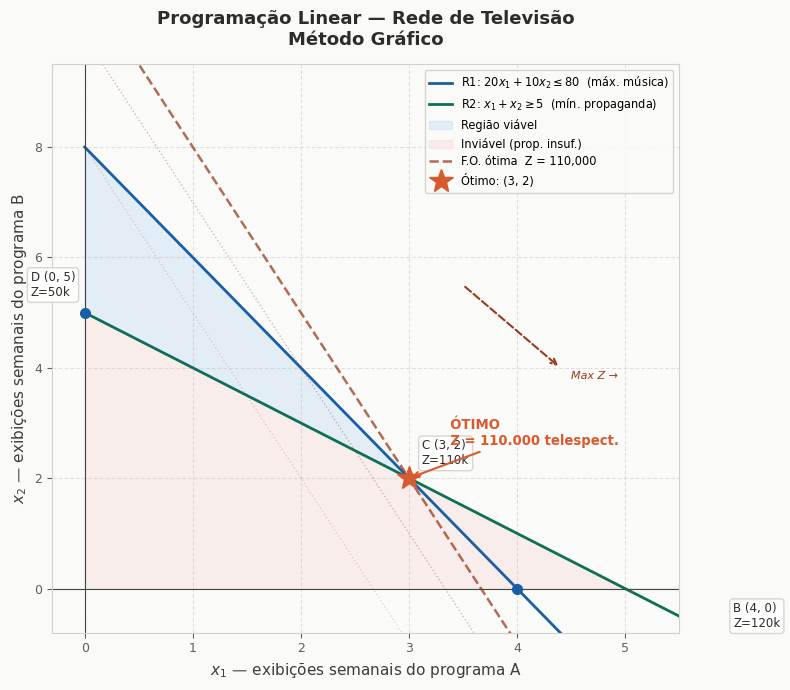

In [12]:
"""
Programação Linear — Rede de Televisão
=======================================

Variáveis de decisão:
    x1 = número de exibições semanais do programa A
    x2 = número de exibições semanais do programa B

Função objetivo:
    Max Z = 30.000·x1 + 10.000·x2

Restrições:
    R1 — música (máx 80 min)   : 20x1 + 10x2 ≤ 80
    R2 — propaganda (mín 5 min): x1  +  x2  ≥  5
    R3 — não-negatividade      : x1 ≥ 0, x2 ≥ 0

Observação: a região viável é ILIMITADA superiormente (R2 é ≥),
mas a F.O. ainda tem máximo finito porque R1 limita o lado superior.
"""

# -------------------------------------------------------
# 1. RESOLVER COM SCIPY
# -------------------------------------------------------
# Convertendo R2 para forma padrão: -x1 - x2 ≤ -5
c    = [-30_000, -10_000]
A_ub = [
    [ 20,  10],   # R1: 20x1 + 10x2 ≤ 80
    [ -1,  -1],   # R2: -(x1+x2) ≤ -5  (equivalente a x1+x2 ≥ 5)
]
b_ub = [80, -5]
bounds = [(0, None), (0, None)]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
x1_opt, x2_opt = res.x
Z_opt = -res.fun

# -------------------------------------------------------
# 3. GRÁFICO
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

x1v = np.linspace(0, 5.5, 500)

# Linhas de restrição
x2_R1 = (80 - 20*x1v) / 10          # R1: x2 = (80-20x1)/10
x2_R2 = 5  -  x1v                    # R2: x2 = 5 - x1

ax.plot(x1v, x2_R1, color='#185FA5', lw=2,
        label='R1: $20x_1 + 10x_2 \\leq 80$  (máx. música)')
ax.plot(x1v, x2_R2, color='#0F6E56', lw=2,
        label='R2: $x_1 + x_2 \\geq 5$  (mín. propaganda)')

# Região viável: abaixo de R1 E acima de R2 E x1,x2≥0
# Construída manualmente pelos vértices da parte limitada
# (polígono fechado com borda superior em R1)
x1_fill = np.linspace(0, 4, 300)
y_upper = np.clip((80 - 20*x1_fill) / 10, 0, None)
y_lower = np.clip(5 - x1_fill, 0, None)
# Apenas onde y_upper >= y_lower (região viável)
mask = y_upper >= y_lower - 1e-9
ax.fill_between(x1_fill[mask], y_lower[mask], y_upper[mask],
                color='#B5D4F4', alpha=0.32, label='Região viável')

# Indicação da região inviável abaixo de R2 (faixa hachurada leve)
ax.fill_between(x1v, np.clip(x2_R2, 0, None),
                np.zeros_like(x1v),
                color='#F09595', alpha=0.12, label='Inviável (prop. insuf.)')

# Linhas de nível da F.O.
for z_val, al in [(80_000, 0.20), (100_000, 0.35)]:
    x2_iso = (z_val - 30_000*x1v) / 10_000
    ax.plot(x1v, x2_iso, color='#993C1D', lw=1,
            linestyle=':', alpha=al)
x2_iso_opt = (Z_opt - 30_000*x1v) / 10_000
ax.plot(x1v, x2_iso_opt, color='#993C1D', lw=1.8,
        linestyle='--', alpha=0.75,
        label=f'F.O. ótima  Z = {Z_opt:,.0f}')

# Vértices anotados
pontos = {
    'B': (4,        0,     2,   -0.7),
    'C': (C_pt[0],  C_pt[1], 0.12, 0.25),
    'D': (0,        5,    -0.5, 0.3),
}
for nome, (px, py, dx, dy) in pontos.items():
    zv = 30_000*px + 10_000*py
    ax.plot(px, py, 'o', color='#185FA5', ms=7, zorder=5)
    ax.annotate(
        f'{nome} ({px:.4g}, {py:.4g})\nZ={zv/1000:.0f}k',
        xy=(px, py), xytext=(px+dx, py+dy),
        fontsize=8.5, color='#2C2C2A',
        bbox=dict(boxstyle='round,pad=0.28', fc='white',
                  ec='#D3D1C7', alpha=0.9)
    )

# Ponto ótimo
ax.plot(x1_opt, x2_opt, '*', color='#D85A30', ms=18, zorder=6,
        label=f'Ótimo: ({x1_opt:.0f}, {x2_opt:.0f})')
ax.annotate(
    f'  ÓTIMO\n  Z = {Z_opt/1000:.0f}.000 telespect.',
    xy=(x1_opt, x2_opt),
    xytext=(x1_opt + 0.3, x2_opt + 0.6),
    fontsize=9.5, color='#D85A30', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5)
)

# Seta indicando direção de otimização da F.O.
ax.annotate('', xy=(4.4, 4.0), xytext=(3.5, 5.5),
            arrowprops=dict(arrowstyle='->', color='#993C1D',
                            lw=1.5, linestyle='dashed'))
ax.text(4.5, 3.8, 'Max Z →', fontsize=8, color='#993C1D', style='italic')

ax.axhline(0, color='#444441', lw=0.8)
ax.axvline(0, color='#444441', lw=0.8)
ax.set_xlim(-0.3, 5.5)
ax.set_ylim(-0.8, 9.5)
ax.set_xlabel('$x_1$ — exibições semanais do programa A', fontsize=11, color='#3d3d3a')
ax.set_ylabel('$x_2$ — exibições semanais do programa B', fontsize=11, color='#3d3d3a')
ax.set_title('Programação Linear — Rede de Televisão\nMétodo Gráfico',
             fontsize=13, fontweight='bold', color='#2C2C2A', pad=14)
ax.grid(True, linestyle='--', alpha=0.35, color='#B4B2A9')
ax.tick_params(colors='#5F5E5A', labelsize=9)
for sp in ax.spines.values():
    sp.set_edgecolor('#D3D1C7')

ax.legend(loc='upper right', fontsize=8.2,
          framealpha=0.92, edgecolor='#D3D1C7', facecolor='#FAFAF8')

plt.tight_layout()
plt.show()
plt.close()

> Solução ótima: exibir o programa A 3 vezes e o programa B 2 vezes por semana, atingindo 110.000 telespectadores.

Problema 4:
Uma empresa fabrica 2 modelos de cintos de couro. O modelo M1, de melhor qualidade, requer o
dobro do tempo de fabricação em relação ao modelo M2. Se todos os cintos fossem do modelo M2, a
empresa poderia produzir 1.000 unidades por dia. A disponibilidade de couro permite fabricar 800
cintos de ambos os modelos por dia. Os cintos empregam fivelas diferentes, cuja disponibilidade
diária é de 400 para M1 e 700 para M2. Os lucros unitários são de $ 4,00 para M1 e $ 3,00 para M2. Qual
o programa ótimo de produção que maximiza o lucro total diário da empresa?


Vértices da região viável:
  (   0.0,    0.0)  Z=   0.00  [x1=0, x2=0]
  ( 400.0,    0.0)  Z=1600.00  [x2=0, R3]
  ( 400.0,  200.0)  Z=2200.00  [R1, R3]
  ( 200.0,  600.0)  Z=2600.00  [R1, R2]
  ( 100.0,  700.0)  Z=2500.00  [R2, R4]
  (   0.0,  700.0)  Z=2100.00  [x1=0, R4]


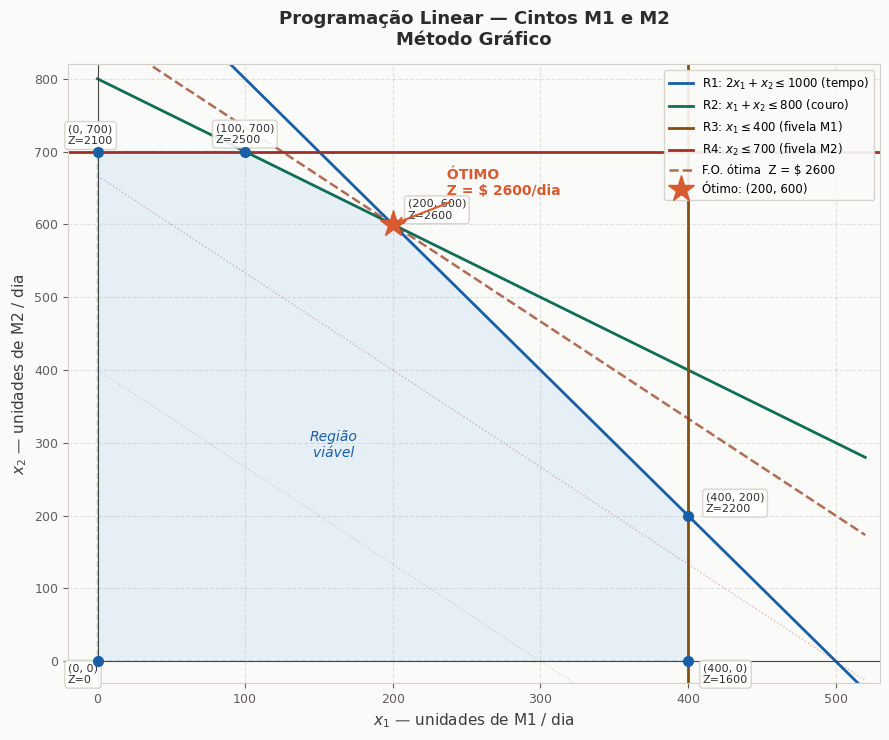

In [14]:
"""
Programação Linear — Cintos M1 e M2
=====================================

Variáveis de decisão:
    x1 = unidades diárias de M1
    x2 = unidades diárias de M2

Função objetivo:
    Max Z = 4·x1 + 3·x2

Restrições:
    R1 — tempo      : 2x1 +  x2 ≤ 1.000
    R2 — couro      :  x1 +  x2 ≤   800
    R3 — fivela M1  :  x1       ≤   400
    R4 — fivela M2  :       x2  ≤   700
    R5 — não-neg.   :  x1, x2   ≥     0

Derivação de R1:
    Capacidade total de tempo = 1.000 × t (unidades de tempo)
    M2 consome t por unidade → x2 * t
    M1 consome 2t por unidade → x1 * 2t
    Total: 2t·x1 + t·x2 ≤ 1000t  →  2x1 + x2 ≤ 1000
"""

# -------------------------------------------------------
# 1. RESOLVER COM SCIPY
# -------------------------------------------------------
c    = [-4, -3]
A_ub = [
    [2, 1],   # R1 tempo
    [1, 1],   # R2 couro
    [1, 0],   # R3 fivela M1
    [0, 1],   # R4 fivela M2
]
b_ub = [1000, 800, 400, 700]
bounds = [(0, None), (0, None)]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
x1_opt, x2_opt = res.x
Z_opt = -res.fun

# -------------------------------------------------------
# 2. TODOS OS VÉRTICES — interseção de pares de fronteiras
# -------------------------------------------------------
fronteiras = [
    (1, 0,  0),    # x1 = 0
    (0, 1,  0),    # x2 = 0
    (2, 1, 1000),  # R1
    (1, 1,  800),  # R2
    (1, 0,  400),  # R3
    (0, 1,  700),  # R4
]

def intersect(l1, l2):
    A = np.array([l1[:2], l2[:2]], dtype=float)
    b = np.array([l1[2],  l2[2]], dtype=float)
    try:
        p = np.linalg.solve(A, b)
        return tuple(np.round(p, 6))
    except np.linalg.LinAlgError:
        return None

def is_feasible(px, py):
    return (px >= -1e-9 and py >= -1e-9 and
            2*px + py <= 1000+1e-9 and
            px + py   <=  800+1e-9 and
            px        <=  400+1e-9 and
            py        <=  700+1e-9)

candidates = set()
for l1, l2 in combinations(fronteiras, 2):
    pt = intersect(l1, l2)
    if pt and is_feasible(*pt):
        candidates.add((round(pt[0],2), round(pt[1],2)))

# Ordenar convex-hull style
verts = list(candidates)
cx = np.mean([v[0] for v in verts])
cy = np.mean([v[1] for v in verts])
verts.sort(key=lambda v: np.arctan2(v[1]-cy, v[0]-cx))

print(f"\nVértices da região viável:")
for vx, vy in verts:
    zv = 4*vx + 3*vy
    ativo = []
    if abs(vx) < 1: ativo.append("x1=0")
    if abs(vy) < 1: ativo.append("x2=0")
    if abs(2*vx+vy-1000) < 1: ativo.append("R1")
    if abs(vx+vy-800) < 1:    ativo.append("R2")
    if abs(vx-400) < 1:       ativo.append("R3")
    if abs(vy-700) < 1:       ativo.append("R4")
    print(f"  ({vx:6.1f}, {vy:6.1f})  Z={zv:7.2f}  [{', '.join(ativo)}]")

# -------------------------------------------------------
# 3. GRÁFICO
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7.5))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

x1v = np.linspace(0, 520, 600)

# Linhas de restrição
ax.plot(x1v, 1000 - 2*x1v,   color='#185FA5', lw=2,
        label='R1: $2x_1 + x_2 \\leq 1000$ (tempo)')
ax.plot(x1v, 800  -   x1v,   color='#0F6E56', lw=2,
        label='R2: $x_1 + x_2 \\leq 800$ (couro)')
ax.axvline(400, color='#854F0B', lw=2,
           label='R3: $x_1 \\leq 400$ (fivela M1)')
ax.axhline(700, color='#A32D2D', lw=2,
           label='R4: $x_2 \\leq 700$ (fivela M2)')

# Região viável (polígono dos vértices)
poly_pts = np.array(verts)
poly = plt.Polygon(poly_pts, closed=True,
                   facecolor='#B5D4F4', alpha=0.28,
                   edgecolor='#185FA5', lw=1.2, linestyle='--')
ax.add_patch(poly)
ax.text(160, 280, 'Região\nviável', fontsize=10,
        color='#185FA5', ha='center', style='italic')

# Linhas de nível da F.O.
for z_val, al in [(1200, 0.18), (2000, 0.32)]:
    x2_iso = (z_val - 4*x1v) / 3
    ax.plot(x1v, x2_iso, color='#993C1D', lw=1, linestyle=':', alpha=al)
x2_iso_opt = (Z_opt - 4*x1v) / 3
ax.plot(x1v, x2_iso_opt, color='#993C1D', lw=1.8,
        linestyle='--', alpha=0.75,
        label=f'F.O. ótima  Z = $ {Z_opt:.0f}')

# Anotações dos vértices
offset_map = {
    (0.0,    0.0):   (-20,  -30),
    (400.0,  0.0):   ( 10,  -30),
    (400.0, 200.0):  ( 12,    5),
    (200.0, 600.0):  ( 10,    8),
    (100.0, 700.0):  (-20,   12),
    (0.0,  700.0):   (-20,   10),
}
for vx, vy in verts:
    zv = 4*vx + 3*vy
    ax.plot(vx, vy, 'o', color='#185FA5', ms=7, zorder=5)
    key = (round(vx,1), round(vy,1))
    dx, dy = offset_map.get(key, (10, 8))
    ax.annotate(
        f'({vx:.4g}, {vy:.4g})\nZ={zv:.0f}',
        xy=(vx, vy), xytext=(vx+dx, vy+dy),
        fontsize=8, color='#2C2C2A',
        bbox=dict(boxstyle='round,pad=0.28', fc='white',
                  ec='#D3D1C7', alpha=0.90)
    )

# Ponto ótimo
ax.plot(x1_opt, x2_opt, '*', color='#D85A30', ms=20, zorder=6,
        label=f'Ótimo: ({x1_opt:.0f}, {x2_opt:.0f})')
ax.annotate(
    f'  ÓTIMO\n  Z = $ {Z_opt:.0f}/dia',
    xy=(x1_opt, x2_opt),
    xytext=(x1_opt + 30, x2_opt + 40),
    fontsize=10, color='#D85A30', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5)
)

ax.axhline(0, color='#444441', lw=0.8)
ax.axvline(0, color='#444441', lw=0.8)
ax.set_xlim(-20, 530)
ax.set_ylim(-30, 820)
ax.set_xlabel('$x_1$ — unidades de M1 / dia', fontsize=11, color='#3d3d3a')
ax.set_ylabel('$x_2$ — unidades de M2 / dia', fontsize=11, color='#3d3d3a')
ax.set_title('Programação Linear — Cintos M1 e M2\nMétodo Gráfico',
             fontsize=13, fontweight='bold', color='#2C2C2A', pad=14)
ax.grid(True, linestyle='--', alpha=0.35, color='#B4B2A9')
ax.tick_params(colors='#5F5E5A', labelsize=9)
for sp in ax.spines.values():
    sp.set_edgecolor('#D3D1C7')

ax.legend(loc='upper right', fontsize=8.5,
          framealpha=0.92, edgecolor='#D3D1C7', facecolor='#FAFAF8')

plt.tight_layout()
plt.show()
plt.close()

> Solução ótima: produzir 200 unidades de M1 e 600 unidades de M2 por dia, gerando um lucro máximo de $ 2.600,00/dia.